In [24]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import rotate_axes

nltk.download('punkt_tab')


df2 = pd.read_csv("../data/tos_for_review.csv")
df2.head()
len(df2)

/home/daniel/Legal-text-simplifier/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/daniel/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt_tab to /home/daniel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


444

In [3]:
tos_test = df2.sample(n=90, random_state=1)
tos_train = df2.drop(tos_test.index)

In [4]:
from summac.model_summac import SummaCZS, SummaCConv

model_zs = SummaCZS(granularity="sentence", model_name="vitc", device="cpu") # If you have a GPU: switch to: device="cuda"
model_conv = SummaCConv(models=["vitc"], bins='percentile', granularity="sentence", nli_labels="e", device="cpu", start_file="default", agg="mean")

document = """Scientists are studying Mars to learn about the Red Planet and find landing sites for future missions.
One possible site, known as Arcadia Planitia, is covered instrange sinuous features.
The shapes could be signs that the area is actually made of glaciers, which are large masses of slow-moving ice.
Arcadia Planitia is in Mars' northern lowlands."""

summary1 = "There are strange shape patterns on Arcadia Planitia. The shapes could indicate the area might be made of glaciers. This makes Arcadia Planitia ideal for future missions."
score_zs1 = model_zs.score([document], [summary1])
score_conv1 = model_conv.score([document], [summary1])
print("[Summary 1] SummaCZS Score: %.3f; SummacConv score: %.3f" % (score_zs1["scores"][0], score_conv1["scores"][0])) # [Summary 1] SummaCZS Score: 0.582; SummacConv score: 0.536

summary2 = "There are strange shape patterns on Arcadia Planitia. The shapes could indicate the area might be made of glaciers."
score_zs2 = model_zs.score([document], [summary2])
score_conv2 = model_conv.score([document], [summary2])
print("[Summary 2] SummaCZS Score: %.3f; SummacConv score: %.3f" % (score_zs2["scores"][0], score_conv2["scores"][0])) # [Summary 2] SummaCZS Score: 0.877; SummacConv score: 0.709

/home/daniel/Legal-text-simplifier/venv/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


<All keys matched successfully>


/home/daniel/Legal-text-simplifier/venv/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/daniel/Legal-text-simplifier/venv/lib/python3.12/site-packages/summac/model_summac.py:298: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  histograms = torch.FloatTensor(histograms).to(self.device)


[Summary 1] SummaCZS Score: 0.582; SummacConv score: 0.536
[Summary 2] SummaCZS Score: 0.877; SummacConv score: 0.709


In [5]:
from summac.model_summac import SummaCZS

model_CZS = SummaCZS(granularity="sentence", model_name="vitc")
model_CONV = SummaCConv(models=["vitc"], bins='percentile', granularity="sentence", nli_labels="e", device="cpu", start_file="default", agg="mean")


original = "The Distributor shall pay the Company a fee of $500 per month."
faithful = "The Distributor pays the Company $500 every month."
corrupted = "The Distributor may pay the Company $500 every month."  # shall -> may

print("CZS: ")
print(model_CZS.score([original], [faithful]))
print(model_CZS.score([original], [corrupted]))
print("CONV: ")
print(model_CONV.score([original], [faithful]))
print(model_CONV.score([original], [corrupted]))

<All keys matched successfully>
CZS: 
{'scores': [np.float64(0.9839954376220703)], 'images': [array([[[0.98583984]],

       [[0.00184441]],

       [[0.01235199]]])]}
{'scores': [np.float64(0.9877872467041016)], 'images': [array([[[9.88769531e-01]],

       [[9.82284546e-04]],

       [[1.04217529e-02]]])]}
CONV: 
{'scores': [0.7673836946487427]}
{'scores': [0.7673836946487427]}


In [6]:
test_pairs_modal_flip= [
    # modal_flip
    {"original": "The Contractor shall complete the work within 30 days.",
     "faithful": "The Contractor is required to finish the work within 30 days.",
     "corrupted": "The Contractor may complete the work within 30 days.",
     "error_type": "modal_flip"},
    {"original": "The Licensee must obtain written consent before sublicensing.",
     "faithful": "The Licensee has to get written permission before sublicensing.",
     "corrupted": "The Licensee should obtain written consent before sublicensing.",
     "error_type": "modal_flip"},
    {"original": "The Buyer shall inspect the goods within five business days.",
     "faithful": "The Buyer is obligated to inspect the goods within five business days.",
     "corrupted": "The Buyer can inspect the goods within five business days.",
     "error_type": "modal_flip"},
    {"original": "The Company will indemnify the Partner against all third-party claims.",
     "faithful": "The Company agrees to indemnify the Partner for all third-party claims.",
     "corrupted": "The Company may indemnify the Partner against all third-party claims.",
     "error_type": "modal_flip"}
]
test_pairs_dropped_clause = [
    # dropped_clause
    {"original": "The Landlord may enter the premises for inspection, provided that 24 hours' notice is given.",
     "faithful": "The Landlord can enter for inspection if they give 24 hours' notice first.",
     "corrupted": "The Landlord may enter the premises for inspection.",
     "error_type": "dropped_clause"},
    {"original": "Either party may terminate this Agreement upon 60 days' written notice, unless a material breach has occurred.",
     "faithful": "Either party can end the agreement with 60 days' written notice, except in cases of a serious breach.",
     "corrupted": "Either party may terminate this Agreement upon 60 days' written notice.",
     "error_type": "dropped_clause"},
    {"original": "The Vendor shall not be liable for delays caused by events beyond its reasonable control, including natural disasters.",
     "faithful": "The Vendor isn't responsible for delays from things outside its control, like natural disasters.",
     "corrupted": "The Vendor shall not be liable for delays.",
     "error_type": "dropped_clause"},
    {"original": "Payment is due within 30 days, except where the Buyer disputes the invoice in good faith.",
     "faithful": "Payment must be made within 30 days, unless the Buyer has a genuine dispute about the invoice.",
     "corrupted": "Payment is due within 30 days.",
     "error_type": "dropped_clause"}
    ]
test_pairs_added_content = [
    # added_content
    {"original": "The Distributor shall pay the Company a fee of $500 per month.",
     "faithful": "The Distributor pays the Company $500 every month.",
     "corrupted": "The Distributor shall pay the Company a fee of $500 per month, plus a 5% late penalty.",
     "error_type": "added_content"},
    {"original": "This Agreement is governed by the laws of the State of Delaware.",
     "faithful": "Delaware law governs this Agreement.",
     "corrupted": "This Agreement is governed by the laws of the State of Delaware and must be arbitrated in New York.",
     "error_type": "added_content"},
    {"original": "The Employee shall receive fifteen days of paid vacation per year.",
     "faithful": "The Employee gets 15 paid vacation days annually.",
     "corrupted": "The Employee shall receive fifteen days of paid vacation per year, which can be carried over indefinitely.",
     "error_type": "added_content"},
    {"original": "The Supplier warrants that the goods are free from material defects.",
     "faithful": "The Supplier guarantees the goods have no major defects.",
     "corrupted": "The Supplier warrants that the goods are free from material defects for a period of five years.",
     "error_type": "added_content"}]
test_pairs_negation = [
    # negation
    {"original": "The Parties agree that this Agreement is not assignable without prior written consent.",
     "faithful": "Neither party can transfer this Agreement without getting written permission first.",
     "corrupted": "The Parties agree that this Agreement is assignable without prior written consent.",
     "error_type": "negation"},
    {"original": "The Licensor does not grant any rights to use the Trademark.",
     "faithful": "The Licensor doesn't give permission to use the Trademark.",
     "corrupted": "The Licensor grants rights to use the Trademark.",
     "error_type": "negation"},
    {"original": "No warranty is made regarding the accuracy of the information provided.",
     "faithful": "There's no guarantee that the information provided is accurate.",
     "corrupted": "A warranty is made regarding the accuracy of the information provided.",
     "error_type": "negation"},
    {"original": "The Tenant shall not sublet the premises without the Landlord's approval.",
     "faithful": "The Tenant can't sublet the property without the Landlord's okay.",
     "corrupted": "The Tenant shall sublet the premises without the Landlord's approval.",
     "error_type": "negation"},
]

for p in test_pairs_modal_flip:
    print("modal flip")
    print("CZS: ")
    print(model_CZS.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CZS.score([p["original"]], [p["corrupted"]])["scores"])
    print("CONV: ")
    print(model_CONV.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CONV.score([p["original"]], [p["corrupted"]])["scores"])
for p in test_pairs_dropped_clause:
    print("dropped clause")
    print("CZS: ")
    print(model_CZS.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CZS.score([p["original"]], [p["corrupted"]])["scores"])
    print("CONV: ")
    print(model_CONV.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CONV.score([p["original"]], [p["corrupted"]])["scores"])
for p in test_pairs_added_content:
    print("added content")
    print("CZS: ")
    print(model_CZS.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CZS.score([p["original"]], [p["corrupted"]])["scores"])
    print("CONV: ")
    print(model_CONV.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CONV.score([p["original"]], [p["corrupted"]])["scores"])
for p in test_pairs_negation:
    print("negation")
    print("CZS: ")
    print(model_CZS.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CZS.score([p["original"]], [p["corrupted"]])["scores"])
    print("CONV: ")
    print(model_CONV.score([p["original"]], [p["faithful"]])["scores"])
    print(model_CONV.score([p["original"]], [p["corrupted"]])["scores"])

modal flip
CZS: 
[np.float64(0.9906158447265625)]
[np.float64(0.9853930473327637)]
CONV: 
[0.869520366191864]
[0.7673836946487427]
modal flip
CZS: 
[np.float64(0.9954671859741211)]
[np.float64(0.9927978515625)]
CONV: 
[0.919477641582489]
[0.869520366191864]
modal flip
CZS: 
[np.float64(0.9801678657531738)]
[np.float64(0.9893808364868164)]
CONV: 
[0.5996683239936829]
[0.869520366191864]
modal flip
CZS: 
[np.float64(0.9872303009033203)]
[np.float64(0.7588043212890625)]
CONV: 
[0.7673836946487427]
[0.22153207659721375]
dropped clause
CZS: 
[np.float64(0.9772348403930664)]
[np.float64(0.9935436248779297)]
CONV: 
[0.6018562316894531]
[0.869520366191864]
dropped clause
CZS: 
[np.float64(0.923126220703125)]
[np.float64(0.9909725189208984)]
CONV: 
[0.35290712118148804]
[0.869520366191864]
dropped clause
CZS: 
[np.float64(0.9949078559875488)]
[np.float64(0.98797607421875)]
CONV: 
[0.919477641582489]


KeyboardInterrupt: 

In [43]:
records = []
test_pairs = [test_pairs_negation, test_pairs_added_content, test_pairs_dropped_clause, test_pairs_modal_flip]
test_pairs_names = ["negation", "added content", "dropped clause", "modal flip"]

for i in range(len(test_pairs)):
    for p in test_pairs[i]:
        czs_f = model_CZS.score([p["original"]], [p["faithful"]])["scores"][0]
        czs_c = model_CZS.score([p["original"]], [p["corrupted"]])["scores"][0]
        czs_f_rev = model_CZS.score([p["faithful"]], [p["original"]])["scores"][0]
        czs_c_rev = model_CZS.score([p["corrupted"]], [p["original"]])["scores"][0]
        conv_f = model_CONV.score([p["original"]], [p["faithful"]])["scores"][0]
        conv_c = model_CONV.score([p["original"]], [p["corrupted"]])["scores"][0]
        conv_f_rev = model_CONV.score([p["faithful"]], [p["original"]])["scores"][0]
        conv_c_rev = model_CONV.score([p["corrupted"]], [p["original"]])["scores"][0]
        records.append({"category": test_pairs_names[i], "model": "CZS", "faithful": czs_f, "corrupted": czs_c})
        records.append({"category": test_pairs_names[i], "model": "CONV_reverse", "faithful": conv_f_rev, "corrupted": conv_c_rev})
        records.append({"category": test_pairs_names[i], "model": "CZS_reverse", "faithful": czs_f_rev, "corrupted": czs_c_rev})
        records.append({"category": test_pairs_names[i], "model": "CONV", "faithful": conv_f, "corrupted": conv_c})

scores_df = pd.DataFrame(records)
scores_df.head(50)

,category,model,faithful,corrupted
0,negation,CZS,0.950630,-0.933868
1,negation,CONV_reverse,0.221532,0.201787
2,negation,CZS_reverse,0.800545,-0.890839
3,negation,CONV,0.349635,0.193518
4,negation,CZS,0.993870,-0.982517
5,negation,CONV_reverse,0.767384,0.200109
6,negation,CZS_reverse,0.986397,-0.997768
7,negation,CONV,0.869520,0.200109
8,negation,CZS,0.993538,-0.962029
9,negation,CONV_reverse,0.869520,0.200109


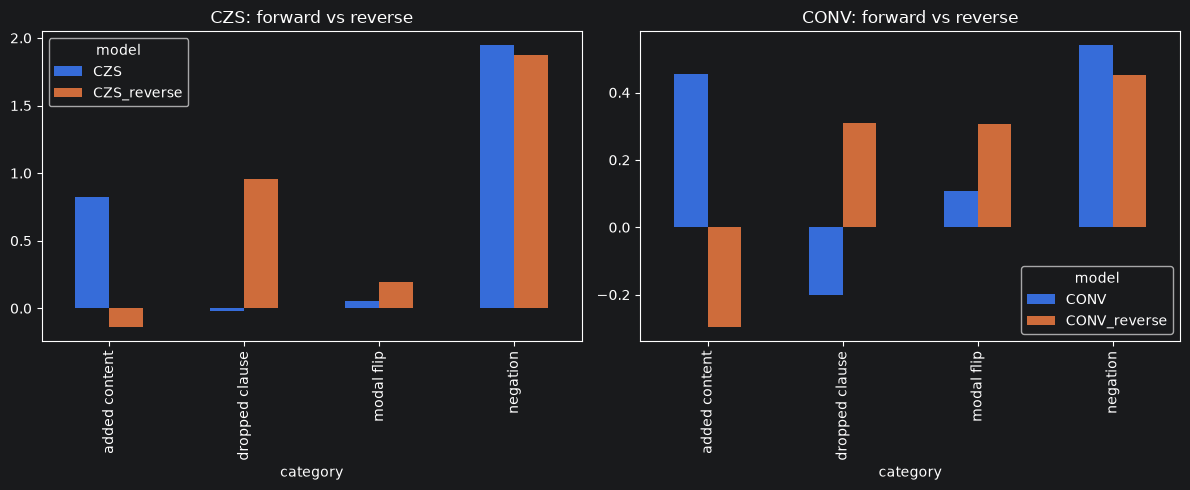

In [45]:
scores_df["gap"] = scores_df["faithful"] - scores_df["corrupted"]
summed_aggregate = scores_df.groupby(["category", "model"])["gap"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
summed_aggregate[["CZS", "CZS_reverse"]].plot(kind="bar", ax=axes[0], title="CZS: forward vs reverse")
summed_aggregate[["CONV", "CONV_reverse"]].plot(kind="bar", ax=axes[1], title="CONV: forward vs reverse")
plt.tight_layout()
plt.savefig("../results/faithfulness_filter_validation.pdf")
plt.show()

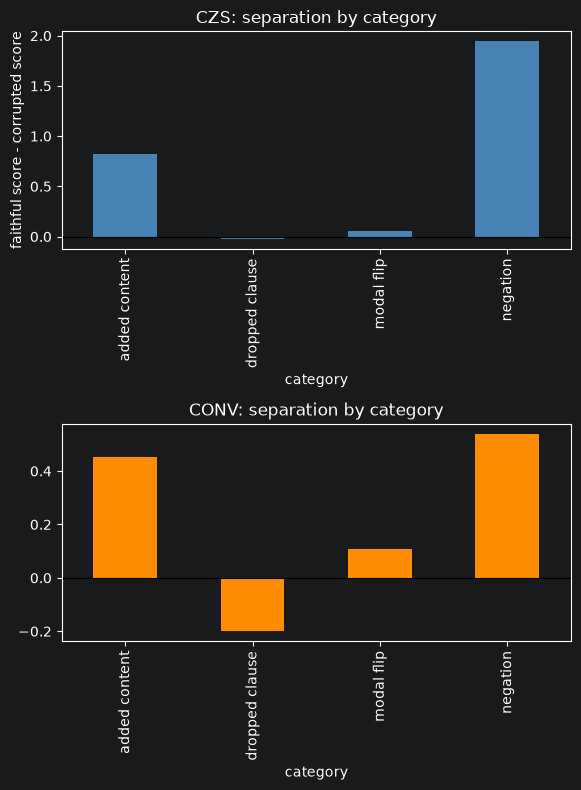

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

summed_aggregate["CZS"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("faithful score - corrupted score")
axes[0].set_title("CZS: separation by category")

summed_aggregate["CONV"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("CONV: separation by category")

plt.tight_layout()
plt.savefig("../results/separation_comparison.pdf")
plt.show()